# E-Commerce Sales Performance — Deeper Analysis

Building on the cleaned data from `01_exploratory_analysis.ipynb`, this notebook
answers focused business questions about **what drives revenue**, **where it
comes from**, and **who the best customers are** — one step per cell.

Aggregation logic lives in `dataanalyst.analysis`, so the notebook and the
README figure script stay in sync.

## 1. Setup and load the cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataanalyst.data import load_processed
from dataanalyst.analysis import (
    kpis,
    avg_revenue_by_discount,
    revenue_pivot,
    top_customers,
    delivery_band,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = load_processed("ecommerce_clean.parquet")
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022-01-01
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022-01-01
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022-01-01
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022-01-01
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022-01-01


## 2. Headline KPIs

A quick scorecard: order count, total revenue, and average order value (AOV).

In [3]:
pd.Series(kpis(df)).round(2)

n_orders                 5000.00
total_revenue         5109775.74
avg_order_value          1021.96
median_order_value        796.65
dtype: float64

## 3. Data-quality check: order dates

Before any time-based analysis, sanity-check the date range. Orders per year
reveal whether the timeline is plausible.

In [4]:
print("date range:", df["order_date"].min().date(), "->", df["order_date"].max().date())
orders_per_year = df["order_date"].dt.year.value_counts().sort_index()
orders_per_year

date range: 2022-01-01 -> 2035-09-09


order_date
2022    365
2023    365
2024    366
2025    365
2026    365
2027    365
2028    366
2029    365
2030    365
2031    365
2032    366
2033    365
2034    365
2035    252
Name: count, dtype: int64

> **Note:** the dates extend to 2035, which is implausible for a real order log.
> Time-trend conclusions should be treated with caution; the analyses below focus
> on dimensions that don't depend on the timeline.

## 4. What is revenue made of?

Confirm the accounting identity so downstream analysis rests on solid ground:
`revenue == quantity x unit_price x (1 - discount)`.

In [5]:
expected = df["quantity"] * df["unit_price"] * (1 - df["discount"])
max_diff = (df["revenue"] - expected).abs().max()
print(f"max absolute difference: {max_diff:.4f}  (0 means revenue is fully derived)")

max absolute difference: 0.0050  (0 means revenue is fully derived)


## 5. How do discounts affect revenue?

`avg_revenue_by_discount` bands the orders and averages revenue within each band.

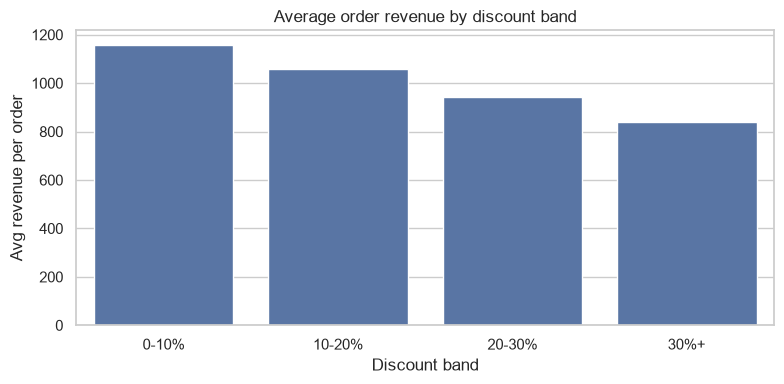

In [6]:
avg_rev_by_discount = avg_revenue_by_discount(df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=avg_rev_by_discount.index.astype(str), y=avg_rev_by_discount.values, ax=ax)
ax.set_title("Average order revenue by discount band")
ax.set_xlabel("Discount band")
ax.set_ylabel("Avg revenue per order")
plt.tight_layout()
plt.show()

## 6. Revenue by category and region

A pivot table crossed with a heatmap shows where revenue concentrates.

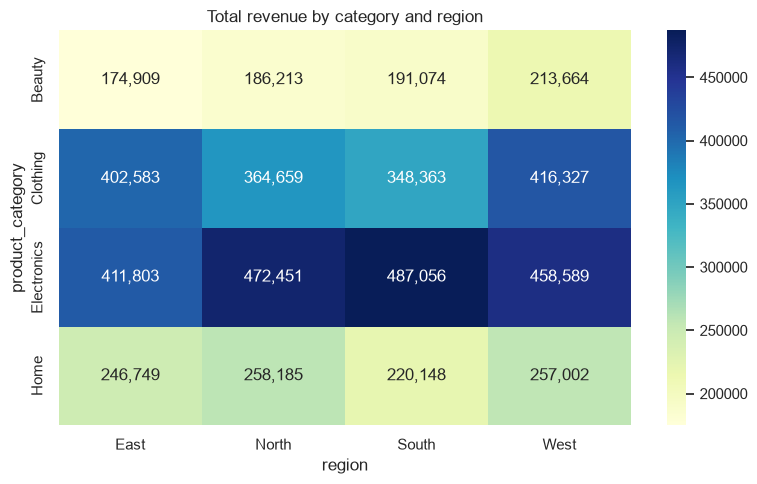

In [7]:
pivot = revenue_pivot(df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", ax=ax)
ax.set_title("Total revenue by category and region")
plt.tight_layout()
plt.show()

## 7. Average order value by category

Total revenue tells you volume; AOV tells you how valuable each order is.

In [8]:
aov_by_category = (
    df.groupby("product_category")["revenue"].mean().sort_values(ascending=False)
)
aov_by_category.round(2)

product_category
Beauty         1059.28
Electronics    1029.77
Home           1013.50
Clothing       1000.61
Name: revenue, dtype: float64

## 8. Who are the top customers?

Rank customers by total revenue — a first step toward retention / VIP analysis.

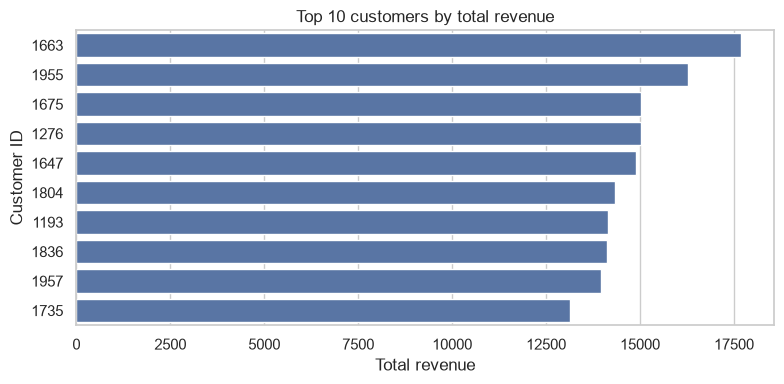

In [9]:
top = top_customers(df, n=10)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=top.values, y=top.index.astype(str), ax=ax)
ax.set_title("Top 10 customers by total revenue")
ax.set_xlabel("Total revenue")
ax.set_ylabel("Customer ID")
plt.tight_layout()
plt.show()

## 9. Does faster delivery mean happier customers?

Compare customer ratings across delivery-time buckets.

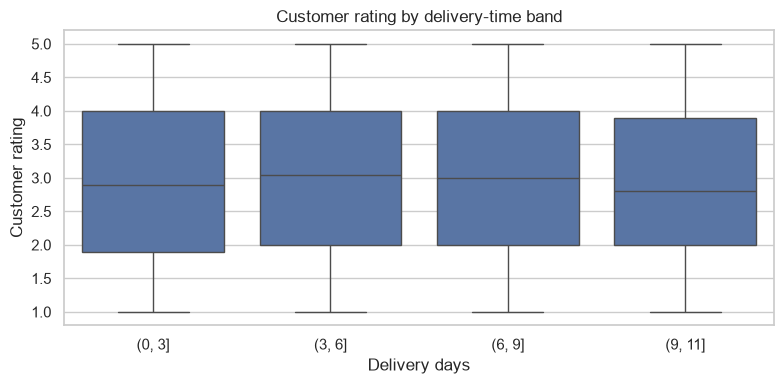

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=delivery_band(df), y=df["customer_rating"], ax=ax)
ax.set_title("Customer rating by delivery-time band")
ax.set_xlabel("Delivery days")
ax.set_ylabel("Customer rating")
plt.tight_layout()
plt.show()

In [11]:
corr = df["delivery_days"].corr(df["customer_rating"])
print(f"correlation(delivery_days, customer_rating) = {corr:.3f}")

correlation(delivery_days, customer_rating) = -0.018


## 10. Conclusions and recommendations

- **Revenue is price- and volume-led.** It equals `quantity x unit_price x (1 - discount)`
  exactly, and correlates most with unit price (0.68) and quantity (0.62).
- **Discounting erodes order value.** Average revenue per order drops from ~1,160
  at low discounts to ~840 above 30% — deep discounts don't pay for themselves here.
  *Recommendation:* cap discounts and test targeted rather than blanket promotions.
- **Electronics and Clothing dominate revenue**, and revenue is evenly spread across
  regions — growth levers are more about category mix than geography.
- **Delivery speed doesn't move ratings** (r ~ -0.02). *Recommendation:* look beyond
  delivery time (product quality, expectations, support) to improve satisfaction.
- **Data caveat:** order dates run to 2035 and should be validated before any
  time-series forecasting.